In [1]:
import sys
sys.path.append('/data/taylor_group/Nima/PandorasBox')

import json
import pickle
import copy 
import random 
import glob

import jax.scipy.linalg as jsl
from tqdm.auto import trange
import tqdm_joblib
from joblib import Parallel, delayed

import numpy as np
import jax.numpy as jnp
import jax.random as jrandom
import jax
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

from jug.engine.session import TimingSession

from Atlas.data import PTA_Data
from Atlas.nMatrix import TM, marg_TM
from Atlas.signals.uncorrelated.base import Uncorrelated, SuperSignal
from Atlas.signals.correlated.base import Correlated
from Atlas import parameterized
from  Atlas.signals.timing.base import build_multi_psr_timing_model, MultiPsrTimingModel
from Atlas.signals.timing.base import setup_timing_model

from Atlas.signals import signals_utils as sutils
import Atlas.utils as atlas_utils
import Atlas.signals.uncorrelated.utils as unc_utils
import Atlas.signals.correlated.utils as cor_utils

import MultiHMCGibbs

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
hist_settings = dict(
    bins = 'auto',
    histtype = 'step', 
    lw = 3,
    density = True
)

plt.style.use('default')
def figsize(scale, wc = 1, hc = 1):
    fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [wc * fig_width,hc * fig_height]
    return fig_size
plt.rcParams.update(plt.rcParamsDefault)

params = {#'backend': 'pdf',
        'axes.labelsize': 12,
        'lines.markersize': 4,
        'font.size': 10,
        'xtick.major.size':6,
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "xtick.major.top": True, 
        "xtick.minor.top": True,
        "ytick.minor.visible": True, 
        "ytick.major.right": True, 
        "ytick.minor.right": True,
        "ytick.direction": "in",
        "xtick.direction": "in",
        'xtick.minor.size':3,  
        'ytick.major.size':6,
        'ytick.minor.size':3, 
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'xtick.minor.width':0.5,
        'ytick.minor.width':0.5,
        'lines.markeredgewidth':1,
        'axes.linewidth':1.2,
        'legend.fontsize': 7,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.dpi':200,
        'path.simplify':True,
        'font.family': 'serif',
        'font.serif':'Times',
        # "text.usetex": True,
        #'text.latex.preamble': [r'\usepackage{amsmath}'],
        'text.usetex':False,
        'figure.figsize': figsize(0.5, 1, 1)}
plt.rcParams.update(params)
plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math

# Loading data

## Option 1: To test the full capability of `ATLAS`, we only need par and tim files.

### We are using the `enterprise` pulsar object. This will be replaced by an in-house object very soon.

In [ ]:
from enterprise.pulsar import Pulsar

In [ ]:
pnames = ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451', 'J0340+4130', 'J0406+3039', 
'J0437-4715', 'J0509+0856', 'J0557+1551', 'J0605+3757', 'J0610-2100', 'J0613-0200', 'J0636+5128', 
'J0645+5158', 'J0709+0458', 'J0740+6620', 'J0931-1902', 'J1012+5307', 'J1012-4235', 'J1022+1001', 
'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902', 'J1455-3330', 'J1600-3053', 'J1614-2230', 
'J1630+3734', 'J1640+2224', 'J1643-1224', 'J1705-1903', #'J1713+0747', 
'J1719-1438', 'J1730-2304', 
'J1738+0333', 'J1741+1351', 'J1744-1134', 'J1745+1017', 'J1747-4036', 'J1751-2857', 'J1802-2124', 
'J1811-2405', 'J1832-0836', 'J1843-1113', 'J1853+1303', 'J1903+0327', 'J1909-3744', 'J1910+1256', 
'J1911+1347', 'J1918-0642', 'J1923+2515', 'J1944+0907', 'J1946+3417', 'J2010-1323', 'J2017+0603', 
'J2033+1734', 'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2214+3000', 'J2229+2643', 'J2234+0611', 
'J2234+0944', 'J2302+4442', 'J2317+1439', 'J2322+2057']
len(pnames)

In [ ]:
# parfiles_ref = sorted(glob.glob('/data/taylor_group/NANOGrav/NG15_v1p1/final_pint_parfiles/*.par'))
# timfiles_ref = sorted(glob.glob('/data/taylor_group/NANOGrav/NG15_v1p1/final_pint_timfiles/*.tim'))
parfiles_ref = sorted(glob.glob('/data/taylor_group/Nima/par/*.par'))
timfiles_ref = sorted(glob.glob('/data/taylor_group/Nima/tim/*.tim'))

### Filter the par and tim files to remove "ao-only" files

In [ ]:
parfiles = []
for pname in pnames:
    for p in parfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            parfiles.append(p)

timfiles = []
for pname in pnames:
    for p in timfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            timfiles.append(p)

In [ ]:
assert len(parfiles) == len(pnames)

In [ ]:
Npulsars = len(pnames) # how many pulsars do you want?
Npulsars

In [ ]:
# def doit(pidx):
#     return Pulsar(parfiles[pidx], timfiles[pidx], ephem='DE440', timing_package='PINT')
# with tqdm_joblib.tqdm_joblib(desc="PINT Loading...", total=len(parfiles)) as progress_bar:
#     psrs = Parallel(n_jobs=24)(delayed(doit)(i) for i in range(len(parfiles)))

# with open('/data/taylor_group/Nima/NG15_v1p1_final_pint_psrs.pkl', 'wb') as fout:
#     pickle.dump(psrs, fout)

In [ ]:
with open('/data/taylor_group/Nima/NG15_v1p1_final_pint_psrs.pkl', 'rb') as fin:
    psrs = pickle.load(fin)
psrs = [psr for psr in psrs if psr.name != 'J1713+0747']

In [ ]:
with open('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

In [ ]:
len(psrs)

## Option 2: If you do not want to vary the timing model params, use the pre-made 15 year pulsar objects.

In [3]:
from enterprise.pulsar import FeatherPulsar
import glob

feather_files = glob.glob('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/*.feather')
psrs = []
for feather_file in feather_files:
    psr = FeatherPulsar.read_feather(feather_file)
    psrs.append(psr)

with open('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

libstempo not installed. PINT or libstempo are required to use par and tim files.


FeatherPulsar.read_feather: cannot find fitpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /data/taylor_group/Nima/15yr_stochasti

# Model Construction

## White Noise Model

In [4]:
choices = {
    1: {'white noise without backend (for simulation studies)' : TM.NoBackendWhiteCov},
    2: {'Timing model marginalized white noise without backend (for simulation studies)' : marg_TM.Marg_NoBackendWhiteCov},
    3: {'white noise with backend (for real data)' : TM.WhiteCov},
    4: {'Timing model marginalized white noise with backend (for real data)' : marg_TM.Marg_WhiteCov}
}
vary_white_noise_params = False

In [5]:
your_choice = 4

In [6]:
if your_choice in [1, 3]:
    vary_timing_residuals = False
else:
    vary_timing_residuals = True

white_noise_model = list(choices[your_choice].values())[0]

In [7]:
data = PTA_Data(psrs, fixed_wn = False, fixed_res=False, linear_timing = False)
N_list = []
pbar = trange(len(psrs))
for pidx in pbar:
    psr = data.psrs[pidx]
    pbar.set_description(f"Construncting White Noise Cov Matrix {psr.name}")
    N_list.append(white_noise_model(psr)
)
wn_model = TM.MultiPulsarWhiteCov(psrs = psrs, cov_matrices = N_list)
data.add_white_noise_cov(wn_model)

  0%|          | 0/67 [00:00<?, ?it/s]

In [9]:
# SAMPLE = ['F0', 'F1'] #psrs[0].fitpars[1:] #
# tm_model = build_multi_psr_timing_model(parfiles[:len(psrs)], 
#                                         timfiles[:len(psrs)], 
#                                         SAMPLE, 
#                                         load_how_many_in_parallel = 24,
#                                         data = data)
# data.add_timing_design_matrix(tm_model.Mmats)

In [10]:
stochastic_res = jnp.concat(data.raw_residuals)

### Initial white noise guess

In [11]:
# theta0_wn = wn_model.prior_draw()
theta0_wn = wn_model.params_dict_to_vector(noise_dict)
theta0_wn[:5]

Array([ 1.11593531,  1.00004904,  1.04311402,  1.11184323, -7.56416433],      dtype=float64)

## Red Noise Model

In [12]:
non_gwb_nfreqs = 30
gwb_nfreqs = 14

### GWB Model

#### Choose your PSD model

In [13]:
# Examples:
# chosen_psd_model, chosen_orf_model, gwb_helper_dictionary = cor_utils.hd_spectrum(renorm_const=1,
#                                                                             crn_bins=gwb_nfreqs,
#                                                                             lower_halflog10_rho=-9.,
#                                                                             upper_halflog10_rho=-2.
#                                                                             )
chosen_psd_model, chosen_orf_model, gwb_helper_dictionary = cor_utils.varied_gamma_hd_pl(renorm_const = 1)
# chosen_psd_model, chosen_orf_model, gwb_helper_dictionary = cor_utils.fixed_gamma_hd_pl(renorm_const = 1)

### Non-GWB Model

#### Choose your PSD model

In [14]:
# Example:
chosen_psd_model_nongwb, helper_dictionary_nongwb = unc_utils.varied_gamma_pl(renorm_const = 1)

In [15]:
sig_unc = Uncorrelated(name='unc', 
                    nfreqs=non_gwb_nfreqs, 
                    halflog10_rho_range=(-9,-2),
                    data = data,
                    use_pulsar_tspan = False) #NOTE: pay attention to this!!!! Is this what you want?

sig_cor = Correlated(name='cor', 
                    nfreqs=gwb_nfreqs, 
                    halflog10_rho_range=(-9,-2),
                    data = data)

# sig_dm = Uncorrelated(name='dm', 
#     nfreqs=non_gwb_nfreqs, 
#     halflog10_rho_range=(-9,-2),
#     data = data,
#     use_pulsar_tspan = False)   

### The user should not see this in the final version, but for now you need to see this!

In [16]:
signal_helper = {
    'shared_basis': { #shared basis does not mean the nfreqs are the same between signals.
                    #It means that one basis includes the other one.
    'signal_list': [sig_unc, sig_cor], 
    'index_of_signal_used_for_basis': 0,
    },

    'separate': {
        'signal_list': []
        },
    'order': 'unc,cor',
    }

In [17]:
sig = SuperSignal(signal_helper = signal_helper, 
                data=data,
)

### `sig.get_helpers` updates the white noise covaraince matrix

In [18]:
TNT, TNr, rNr, logdetN = sig.get_helpers(reff = stochastic_res, white_noise_params=theta0_wn)
TNT.shape, TNr.shape, rNr.shape, logdetN.shape

E0622 00:18:22.367700 3538791 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %gather.9590 = f64[88680,1,423]{2,1,0} gather(%constant.8395, %constant.23179), offset_dims={1,2}, collapsed_slice_dims={}, start_index_map={0}, index_vector_dim=1, slice_sizes={1,423}, metadata={op_name="jit(get_helpers)/jit(solve)/jit(solve)/gather" stack_frame_id=317}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0622 00:18:22.522174 3537496 slow_operation_alarm.cc:140] The operation took 1.154575467s
Constant folding an instruction is taking > 1s:

  %gather.9590 = f64[88680,1,423]{2,1,0} gather(%constant.8395, %constant.2317

((67, 60, 60), (67, 60), (1, 1), (1,))

In [28]:
# %timeit sig.get_helpers(reff = stochastic_res, white_noise_params=theta0_wn)

In [19]:
ll, ul = wn_model.get_prior_bounds() #white noise prior bounds
ll[:5], ul[:5]

(Array([ 0.01,  0.01,  0.01,  0.01, -9.  ], dtype=float64),
 Array([10., 10., 10., 10., -5.], dtype=float64))

## Combine non-GWB with GWB

In [20]:
gwb_Tspan = data.pta_tspan
gwb_Tspan/(365.25 * 86400)

16.029777268872298

In [21]:
o = parameterized.MultiPulsarRedNoise(
            # ---- GWB ----
            gwb_psd_func = chosen_psd_model,
            orf_func = chosen_orf_model,
            crn_bins = gwb_nfreqs,
            int_bins = non_gwb_nfreqs,
            f_common = sig_cor.freqs, 
            f_intrin = sig_unc.freqs,
            df = 1/gwb_Tspan,
            Tspan = gwb_Tspan, 
            Npulsars = sig.npsrs,
            psr_pos = data.psr_pos,
            gwb_helper_dictionary = gwb_helper_dictionary,
            renorm_const = 1,
            
            # ---- non-GWB intrinsic red noise (optional) ----
            irn_psd_func=chosen_psd_model_nongwb,
            irn_helper_dictionary=helper_dictionary_nongwb,

            # dm_psd_func=chosen_psd_model_nongwb,
            # dm_helper_dictionary=helper_dictionary_nongwb,
            # f_dm = sig_unc.freqs,
            # dm_bins = len(sig_unc.freqs)
            )
sig.add_model(o)

In [22]:
x0 = o.make_initial_guess(jrandom.key(1273442)) #red noise model params
phi0 = o.get_phi_mat_full(x0) #red noise cov matrix
phi0.shape, x0.shape

((30, 67, 67), (136,))

# Likelihood

### Reparameterized likelihood

In [23]:
z0 = jrandom.normal(jrandom.key(10098), shape = (sig.npsrs, sig.nmodes)) # re-parameterized coefficients

In [24]:
lnprob0, coeff0 = sig.lnposterior_reparam(helpers = (TNT, TNr), 
                                            red_params = x0, 
                                            z = z0)
lnprob0

Array(46168.50040148, dtype=float64)

In [35]:
%timeit lnprob0, coeff0 = sig.lnposterior_reparam(helpers = (TNT, TNr), red_params = x0, z = z0)

2.13 ms ± 416 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [36]:
z0 = jrandom.normal(jrandom.key(10098), shape = (sig.npsrs, sig_cor.nmodes)) # re-parameterized coefficients

In [38]:
# lnprob0, coeff0 = sig.lnposterior_partial_marg_reparam(helpers = (TNT, TNr), 
#                                             red_params = x0, 
#                                             z = z0)
# lnprob0

In [39]:
# %timeit lnprob0, coeff0 = sig.lnposterior_partial_marg_reparam(helpers = (TNT, TNr), red_params = x0, z = z0)

[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[FITTER] noise_config was None, auto-detecting from par file
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[FITTER] noise_config was None, auto-detecting from par file
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[FITTER] noise_config was None, auto-detecting from par file
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[FITTER] noise_config was None, auto-detecting from par file
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[FITTER] noise_config was None, auto-detecting from par file
[!] Unr

# Timing Model

### `z_tm` is the value by which the deviations from the best fit are changed. This is an inferable parameter

In [53]:
z_tm = {}
for pidx in range(sig.npsrs):
    z_tm.update({f'z_{k};{pidx}': 100 * jrandom.normal(jrandom.key(random.randint(0, 16162))) for k in SAMPLE})
z_tm 

{'z_F0;0': Array(56.17421588, dtype=float64),
 'z_F1;0': Array(95.17331724, dtype=float64),
 'z_F0;1': Array(126.45349733, dtype=float64),
 'z_F1;1': Array(101.52472641, dtype=float64),
 'z_F0;2': Array(61.45972932, dtype=float64),
 'z_F1;2': Array(-83.64406974, dtype=float64),
 'z_F0;3': Array(106.568722, dtype=float64),
 'z_F1;3': Array(5.72887435, dtype=float64),
 'z_F0;4': Array(-110.85017309, dtype=float64),
 'z_F1;4': Array(176.52750706, dtype=float64),
 'z_F0;5': Array(68.59142354, dtype=float64),
 'z_F1;5': Array(-115.64650099, dtype=float64),
 'z_F0;6': Array(-34.4868905, dtype=float64),
 'z_F1;6': Array(-199.13432673, dtype=float64),
 'z_F0;7': Array(48.25686685, dtype=float64),
 'z_F1;7': Array(-215.90383195, dtype=float64),
 'z_F0;8': Array(115.09220499, dtype=float64),
 'z_F1;8': Array(31.87661599, dtype=float64),
 'z_F0;9': Array(82.96325278, dtype=float64),
 'z_F1;9': Array(-26.50499162, dtype=float64),
 'z_F0;10': Array(74.13252587, dtype=float64),
 'z_F1;10': Array(134

In [54]:
z_tm_concat = jnp.array(list(z_tm.values()))
assert z_tm_concat.shape[0] == len(psrs) * len(SAMPLE)

In [55]:
tm_model.residuals(z_tm_concat),tm_model.residuals(z_tm_concat).shape

(Array([-1.72916263e-06, -1.87374444e-06, -9.94587975e-07, ...,
        -1.13865246e-06,  2.40958483e-06,  2.98201494e-06], dtype=float64),
 (615294,))

In [48]:
%timeit tm_model.residuals(z_tm_concat)

2.45 ms ± 8.57 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [49]:
tm_param_dim = len(z_tm_concat)
tm_param_dim 

128

# Sampling

In [25]:
stochastic_res

Array([-1.57059796e-06, -1.71515979e-06, -8.36003331e-07, ...,
       -9.44333405e-07,  2.60359041e-06,  3.17602052e-06], dtype=float64)

### NOTE: Comment out the parts of the model you do not want to sample

### NOTE: If you want to fix the white noise to the NG15 noise dictionary, make sure you use the white noise dictionary to make the TNT, TNr matricies instead of prior draws.

In [26]:
def model():

    ######################################## Timing Model ########################################
    # Declare the variables in the model
    # z_tm_concat = numpyro.sample('z_tm_concat', dist.Normal(0, 100).expand([tm_param_dim]))
    # stochastic_res = tm_model.residuals(z_tm_concat)

    ######################################## White Noise ########################################
    # Declare the variables in the model
    theta_wn = numpyro.sample('theta_wn', dist.Uniform(ll, ul))

    # Update the white noise covaraince matrix
    TNT, TNr, rNr, logdet_N = sig.get_helpers(reff = stochastic_res, white_noise_params=theta_wn)

    # White noise direct contribution to the PTA likelihood
    numpyro.factor('lnpost_white', -0.5 * (rNr[0] + logdet_N))

    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', dist.Uniform(o.lower_prior_lim_all, o.upper_prior_lim_all)) #PSD params
    z_a = numpyro.sample('z_a', dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))) #the reparam coefficients

    # evaluate the posterior
    lprob, coeff = sig.lnposterior_reparam(helpers = (TNT, TNr), red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob)

    # numpyro.deterministic('coeff', coeff)

## Not Block Gibbs

In [ ]:
mcmc_bad = MCMC(
    NUTS(model),
    num_warmup=1000,
    num_samples=4000,
    num_chains=1,
    # chain_method=chain_method,
    progress_bar=True
)
mcmc_bad.run(jrandom.key(100))

In [29]:
samples = mcmc_bad.get_samples()['xs']
samples.shape

(4000, 136)

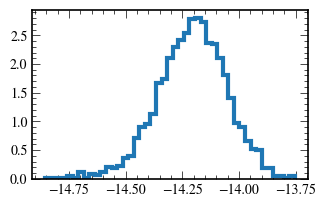

In [32]:
plt.hist(samples[:, -2], **hist_settings)
plt.show()

In [35]:
x0[-5:]

Array([-15.18464388,   6.62363053, -14.21608465, -16.06889042,
         5.07896501], dtype=float64)

In [59]:
sig.lnposterior_reparam(helpers = (TNT, TNr), red_params = x0, z = z0)

(Array(745690.65765587, dtype=float64),
 Array([[ 4.68745701e-07,  1.71848554e-08,  1.93842830e-08, ...,
          9.37389356e-10,  3.49841484e-10, -4.06520634e-10],
        [-1.13145131e-07,  8.19239913e-06, -3.36127356e-07, ...,
          2.74492112e-09,  8.00851195e-10, -1.75477463e-09],
        [ 1.94349415e-08,  1.80406313e-07, -3.03579384e-07, ...,
          3.59223760e-10, -1.02221800e-09,  1.03154801e-09],
        ...,
        [-4.70837737e-08,  2.50350576e-09,  2.77168945e-08, ...,
          2.10744767e-10,  1.13018214e-09,  1.65838799e-09],
        [ 7.99583952e-09, -3.97858693e-09, -3.94900066e-09, ...,
         -8.29318989e-10, -8.70382119e-10,  7.84315138e-10],
        [ 2.48969673e-06,  6.09636691e-07, -2.52153689e-06, ...,
         -1.32527958e-09, -1.71768962e-10,  8.53280132e-11]],      dtype=float64))

In [ ]:
sig_unc.lnposterior_reparam(helpers = (TNT, TNr), red_noise_cov=o.get_phi_mat_full(x0), z = z0)

(Array(745690.65765599, dtype=float64),
 Array([[ 4.68745701e-07,  1.71848554e-08,  1.93842830e-08, ...,
          9.37389356e-10,  3.49841484e-10, -4.06520634e-10],
        [-1.13145131e-07,  8.19239913e-06, -3.36127356e-07, ...,
          2.74492112e-09,  8.00851195e-10, -1.75477463e-09],
        [ 1.94349415e-08,  1.80406313e-07, -3.03579384e-07, ...,
          3.59223760e-10, -1.02221800e-09,  1.03154801e-09],
        ...,
        [-4.70837737e-08,  2.50350576e-09,  2.77168945e-08, ...,
          2.10744767e-10,  1.13018214e-09,  1.65838799e-09],
        [ 7.99583952e-09, -3.97858693e-09, -3.94900066e-09, ...,
         -8.29318989e-10, -8.70382119e-10,  7.84315138e-10],
        [ 2.48969673e-06,  6.09636691e-07, -2.52153689e-06, ...,
         -1.32527958e-09, -1.71768962e-10,  8.53280132e-11]],      dtype=float64))

In [62]:
sig_unc.add_model(o)

## Block Gibbs (Nima is still improving this. Might be buggy!)

In [ ]:
kernel = MultiHMCGibbs.MultiHMCGibbs([NUTS(model)] * 2,
                        [
                            ['theta_wn'],
                            ['xs', 'z_a']
                        ])

mcmc = MCMC(
    kernel,
    num_warmup=1000,
    num_samples=4000,
    num_chains=1,
    # chain_method=chain_method,
    progress_bar=True
)
mcmc.run(jrandom.key(100))


ValueError: Expected each site to be listed **exactly once**. Following sites in the model but not listed: ['theta_wn_base']. Following sites listed but not in the model: ['theta_wn'].